In [1]:
#导入必备的工具
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
trans=transforms.ToTensor()#预处理：变为张量并归一化（灰度值除255）
train_data=datasets.MNIST(root='data',train=True,download=True,transform=trans)
test_data=datasets.MNIST(root='data',train=False,download=True,transform=trans)
train_iter=DataLoader(train_data,batch_size=256,shuffle=True)
test_iter=DataLoader(test_data,batch_size=256,shuffle=False)


In [3]:
#定义网络,先展平（256，28*28），全连接层（输入）-激活函数-全连接层（输出）
net=nn.Sequential(nn.Flatten(),nn.Linear(784,256),nn.ReLU(),nn.Dropout(0.5),nn.Linear(256,10))

In [4]:
loss=nn.CrossEntropyLoss()#交叉熵损失
trainer=torch.optim.SGD(net.parameters(),lr=0.1)

In [5]:
num_epochs=20#训练10轮
train_loss_history=[]#记录loss
test_acc_history=[]#记录accuracy

for epoch in range(num_epochs):
    net.train()#训练模式
    total_loss,num_batches=0.0,0
    for X,y in train_iter:
        y_hat=net(X)#前向传播
        l=loss(y_hat,y)
        trainer.zero_grad()#清梯度
        l.backward()#反向传播
        trainer.step()
        total_loss+=l.item()#张量变标量累加
        num_batches+=1
    avg_loss=total_loss/num_batches
    train_loss_history.append(avg_loss)#画图用

    net.eval()#测试模式
    correct,total=0,0
    with torch.no_grad():#测试时不记录梯度 省内存
        for X,y in test_iter:
            y_hat=net(X)
            correct+=(y_hat.argmax(dim=1)==y).sum().item()#数一数做对了几道
            total+=y.shape[0]
    acc=correct/total
    test_acc_history.append(acc)
    print(f'epoch{epoch+1}:loss={avg_loss:.4f},test_acc={acc:.4f}')

epoch1:loss=0.8617,test_acc=0.8989
epoch2:loss=0.4147,test_acc=0.9170
epoch3:loss=0.3456,test_acc=0.9276
epoch4:loss=0.3014,test_acc=0.9347
epoch5:loss=0.2716,test_acc=0.9405
epoch6:loss=0.2484,test_acc=0.9467
epoch7:loss=0.2306,test_acc=0.9480
epoch8:loss=0.2168,test_acc=0.9530
epoch9:loss=0.2032,test_acc=0.9546
epoch10:loss=0.1925,test_acc=0.9578
epoch11:loss=0.1823,test_acc=0.9585
epoch12:loss=0.1761,test_acc=0.9615
epoch13:loss=0.1661,test_acc=0.9621
epoch14:loss=0.1609,test_acc=0.9632
epoch15:loss=0.1551,test_acc=0.9642
epoch16:loss=0.1487,test_acc=0.9661
epoch17:loss=0.1462,test_acc=0.9676
epoch18:loss=0.1404,test_acc=0.9676
epoch19:loss=0.1366,test_acc=0.9698
epoch20:loss=0.1338,test_acc=0.9694


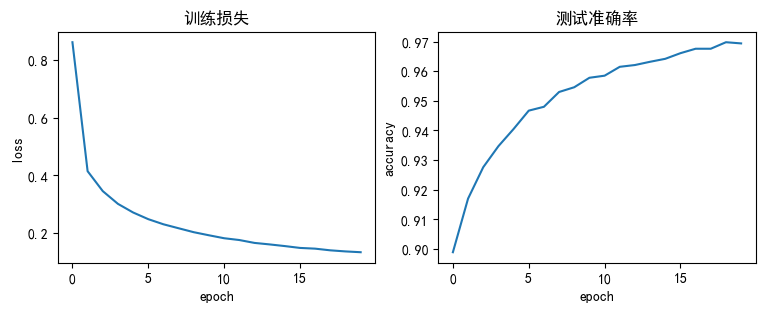

In [6]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('训练损失')
plt.subplot(1, 2, 2)
plt.plot(test_acc_history)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('测试准确率')
plt.show()

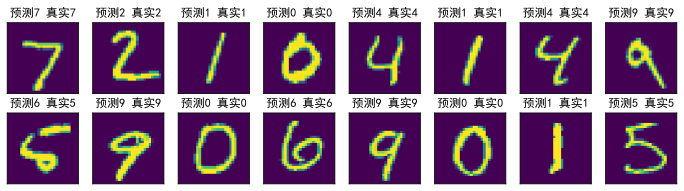

In [7]:
X,y=next(iter(test_iter))
with torch.no_grad():
    y_hat=net(X)
preds=y_hat.argmax(dim=1)
from d2l import torch as d2l 
d2l.set_figsize((7,3.5))
d2l.show_images(X[:16].reshape(16, 28, 28), 2, 8,
                titles=[f'预测{p} 真实{t}' for p, t in zip(preds[:16], y[:16])])
plt.show()